This notebook implements a two-stage Deep Neural Network pipeline for vehicular Mobile Edge Computing (MEC) server selection, following the architecture: Input Features → DNN → Predict Server Load → Estimate Latency → Select Best Server.

Stage 1 uses a feedforward DNN to predict Server_Load_Percent for a given vehicle-server pair, based on vehicle and environmental features (speed, traffic density, road type, weather, data type, urgency, location, and candidate server ID). Stage 2 uses a second DNN to estimate Latency_ms, using the predicted load from Stage 1 along with vehicle-side conditions. Stage 3 scores every candidate MEC server for each test vehicle using the trained models, and selects the server with the lowest predicted latency.

In [1]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers
df = pd.read_csv("mec_training_dataset_v2.csv")
import numpy as np
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df["Vehicle_ID"]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

print(f"Train rows: {len(train_df)}  Test rows: {len(test_df)}  "
      f"(Train vehicles: {train_df['Vehicle_ID'].nunique()}, Test vehicles: {test_df['Vehicle_ID'].nunique()})")

Train rows: 7854  Test rows: 1965  (Train vehicles: 160, Test vehicles: 40)


In [2]:
# ---------------------------------------------------------------------------
# STAGE 1 -- Predict Server_Load_Percent
# ---------------------------------------------------------------------------
stage1_num = ["Speed_kmh", "Traffic_Density", "Urgency_Level", "Latitude", "Longitude"]
stage1_cat = ["Road_Type", "Weather", "Data_Type", "MEC_Server_ID"]
stage1_target = "Server_Load_Percent"

stage1_pre = ColumnTransformer([
    ("num", StandardScaler(), stage1_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), stage1_cat),
])

X1_train = stage1_pre.fit_transform(train_df[stage1_num + stage1_cat])
X1_test = stage1_pre.transform(test_df[stage1_num + stage1_cat])  # transform only, no fit -> avoids leakage
y1_train = train_df[stage1_target].values
y1_test = test_df[stage1_target].values

stage1_model = keras.Sequential([
    layers.Input(shape=(X1_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
])

stage1_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

history1 = stage1_model.fit(X1_train, y1_train, validation_split=0.15, epochs=150,
                             batch_size=64, verbose=1)

pred_load_train = stage1_model.predict(X1_train, verbose=0).flatten()
pred_load_test = stage1_model.predict(X1_test, verbose=0).flatten()

print("\n--- Stage 1: Server_Load_Percent prediction ---")
print(f"Test R2:  {r2_score(y1_test, pred_load_test):.4f}")
print(f"Test MAE: {mean_absolute_error(y1_test, pred_load_test):.2f} points")

Epoch 1/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 3812.5144 - mae: 50.8289 - val_loss: 301.0821 - val_mae: 14.1002
Epoch 2/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 187.9742 - mae: 10.6752 - val_loss: 70.1687 - val_mae: 6.3420
Epoch 3/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 65.9266 - mae: 6.4503 - val_loss: 17.7790 - val_mae: 3.2569
Epoch 4/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37.1003 - mae: 4.8800 - val_loss: 6.4569 - val_mae: 1.9639
Epoch 5/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 31.1332 - mae: 4.3906 - val_loss: 3.7939 - val_mae: 1.5869
Epoch 6/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.6002 - mae: 4.1350 - val_loss: 2.2150 - val_mae: 1.1698
Epoch 7/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.6758 - mae: 3.9473 - val_loss: 1.4088 - val_mae: 0.9258
Epoch 8/150
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24.3945 - mae: 3.8619 - val_loss: 1.1491 - val_mae: 0.8757
Epoch 9/150
105/105 ━━━━━━━━━━

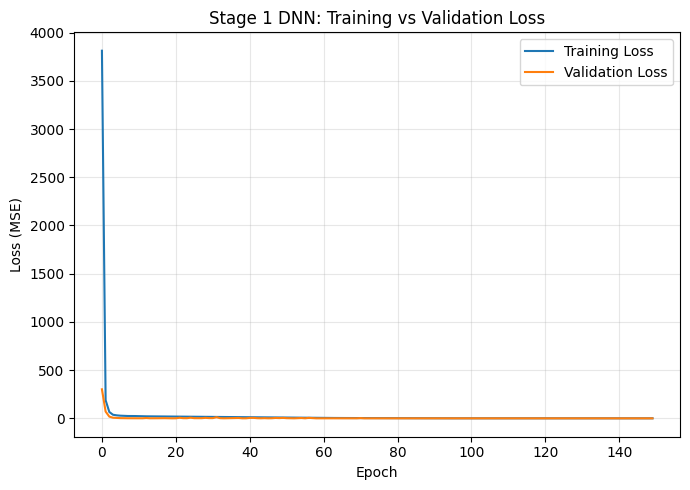

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Stage 1 DNN: Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('stage1_dnn_loss_curve.png', dpi=300)
plt.show()

In [9]:
# ---------------------------------------------------------------------------
# STAGE 2 -- Estimate Network Latency (uses PREDICTED load from Stage 1,
# not the true load, since at inference time true load is unknown)
# ---------------------------------------------------------------------------
train_df["Pred_Load"] = pred_load_train

test_df["Pred_Load"] = pred_load_test


stage2_num = ["Pred_Load", "Speed_kmh", "Traffic_Density", "Latitude", "Longitude", "Urgency_Level"]
stage2_cat = ["Road_Type", "Weather", "Data_Type", "MEC_Server_ID"]
stage2_target = "Latency_ms"


stage2_pre = ColumnTransformer([
    ("num", StandardScaler(), stage2_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), stage2_cat),
])


X2_train = stage2_pre.fit_transform(train_df[stage2_num + stage2_cat])


X2_test = stage2_pre.transform(test_df[stage2_num + stage2_cat])


y2_train = train_df[stage2_target].values


y2_test = test_df[stage2_target].values


stage2_model = keras.Sequential([
    layers.Input(shape=(X2_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.15),
    layers.Dense(32, activation="relu"),
    layers.Dense(1),
])


stage2_model.compile(optimizer="adam", loss="mse", metrics=["mae"])


history2=stage2_model.fit(X2_train, y2_train, validation_split=0.15, epochs=40,
                  batch_size=64, verbose=0)

pred_latency_test = stage2_model.predict(X2_test, verbose=0).flatten()

test_df["Pred_Latency"] = pred_latency_test

print("\n--- Stage 2: Latency prediction (from PREDICTED load) ---")
print(f"Test R2:  {r2_score(y2_test, pred_latency_test):.4f}")

print(f"Test MAE: {mean_absolute_error(y2_test, pred_latency_test):.2f} ms")


KeyboardInterrupt: 

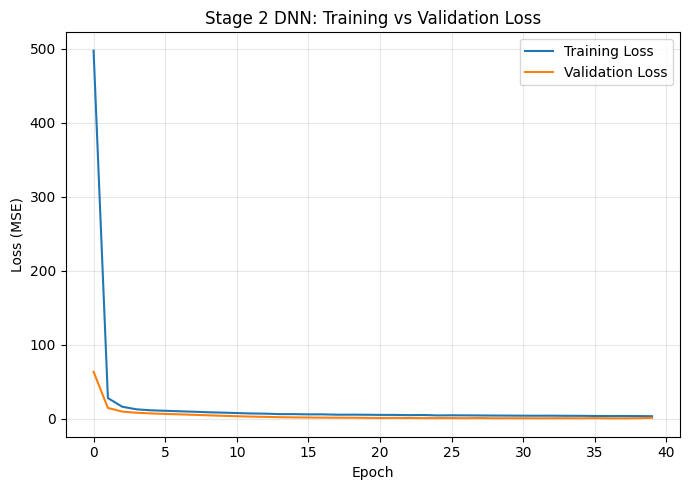

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Stage 2 DNN: Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('stage2_dnn_loss_curve.png', dpi=300)
plt.show()

In [6]:
test_vehicles = test_df["Vehicle_ID"].unique()
all_servers = df["MEC_Server_ID"].unique()

rows = []
for vid in test_vehicles:
    vehicle_row = test_df[test_df["Vehicle_ID"] == vid].iloc[0]
    for server_id in all_servers:
        row = vehicle_row.copy()
        row["MEC_Server_ID"] = server_id
        rows.append(row)

candidates = pd.DataFrame(rows)
candidates = candidates.reset_index(drop=True)

X1_cand = stage1_pre.transform(candidates[stage1_num + stage1_cat])
candidates["Pred_Load"] = stage1_model.predict(X1_cand, verbose=0).flatten()

X2_cand = stage2_pre.transform(candidates[stage2_num + stage2_cat])
candidates["Pred_Latency"] = stage2_model.predict(X2_cand, verbose=0).flatten()

best_choice = candidates.loc[candidates.groupby("Vehicle_ID")["Pred_Latency"].idxmin()]

print("Shape of best_choice:", best_choice.shape)
print("Unique vehicles:", best_choice["Vehicle_ID"].nunique())
print(best_choice["MEC_Server_ID"].value_counts())

Shape of best_choice: (40, 16)
Unique vehicles: 40
MEC_Server_ID
6.0    14
2.0    13
5.0     6
4.0     4
3.0     2
1.0     1
Name: count, dtype: int64


In [7]:
print("Train target std:", train_df["Server_Load_Percent"].std())
print("Test target std:", test_df["Server_Load_Percent"].std())
print(test_df["Server_Load_Percent"].describe())

Train target std: 25.82193133427927
Test target std: 28.58566275064528
count    1965.000000
mean       76.785491
std        28.585663
min        13.670000
25%        69.500000
50%        95.500000
75%       100.000000
max       100.000000
Name: Server_Load_Percent, dtype: float64


In [8]:
import numpy as np
def prediction_accuracy(y_true, y_pred):
    mask = np.array(y_true) != 0
    mape = np.mean(np.abs((np.array(y_true)[mask] - np.array(y_pred)[mask]) / np.array(y_true)[mask])) * 100
    return 100 - mape

print(f"Stage 1 Accuracy: {prediction_accuracy(y1_test, pred_load_test):.2f}%")
print(f"Stage 2 Accuracy: {prediction_accuracy(y2_test, pred_latency_test):.2f}%")

Stage 1 Accuracy: 99.48%
Stage 2 Accuracy: 94.79%
